# Notebook 02 — Data Preprocessing Pipeline
## COM668 Final Year Project: AI-Based Intrusion Detection System
**Student:** Abdulbosit Abdurazzakov | **ID:** B00979380

---

### Purpose
This notebook implements the full data preprocessing pipeline.  
All steps are applied in strict sequence to prevent data leakage between training and test sets.

### Key Design Decisions (Video Walkthrough Reference)
| Decision | Rationale |
|---|---|
| **Temporal split** (Mon–Wed train / Thu–Fri test) | Prevents leakage from temporally correlated flows; reflects real deployment |
| **Binary labels** (BENIGN vs ATTACK) | Reduces impact of rare classes; improves detection recall |
| **RandomOverSampler on training data only** | Corrects 5.3:1 imbalance without contaminating the test set |
| **StandardScaler fitted on training data only** | Prevents test statistics from influencing normalisation |


---
## 1. Environment Setup

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import RandomOverSampler

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Create output directories if they do not exist
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print("Libraries loaded.")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  Working dir: {os.getcwd()}")


Libraries loaded.
  pandas     : 2.3.2
  numpy      : 2.3.2
  Working dir: c:\Projects\cyber_ids_project\notebooks


---
## 2. Loading CICIDS2017 Data — Temporal Split

### Why a Temporal Split?
A **random 80/20 split** was explored in Notebook 01 and produced near-perfect F1 scores (1.00).  
These results are misleading because network flows captured in the same session are  
**temporally correlated** — similar flows appear in both train and test, inflating metrics.

The correct approach is a **temporal split**:
- **Training set**: Monday, Tuesday, Wednesday captures
- **Test set**: Thursday, Friday captures

This simulates real-world deployment: the model is trained on historical data and  
evaluated on future, unseen traffic — including attack types it has never encountered.

> ⚠️ Note: the attack types in the test set (PortScan, DDoS, Bot, Web Attacks) are  
> **completely different** from the training set (DoS, FTP-Patator, SSH-Patator).  
> This is a deliberate and honest evaluation of the model's generalisation ability.


In [12]:
DATA_DIR = '../data'

TRAIN_FILES = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
]

TEST_FILES = [
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

def load_csv_files(file_list, data_dir):
    """Load, concatenate and strip column whitespace from multiple CSV files."""
    dfs = []
    for fname in file_list:
        path = os.path.join(data_dir, fname)
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()
        print(f"  Loaded: {fname}  ({df.shape[0]:,} rows)")
        dfs.append(df)
    return pd.concat(dfs, axis=0, ignore_index=True)

print("Loading TRAINING data (Monday – Wednesday)...")
df_train = load_csv_files(TRAIN_FILES, DATA_DIR)
print(f"  -> Training shape: {df_train.shape}\n")

print("Loading TEST data (Thursday – Friday)...")
df_test = load_csv_files(TEST_FILES, DATA_DIR)
print(f"  -> Test shape: {df_test.shape}")


Loading TRAINING data (Monday – Wednesday)...
  Loaded: Monday-WorkingHours.pcap_ISCX.csv  (529,918 rows)
  Loaded: Tuesday-WorkingHours.pcap_ISCX.csv  (445,909 rows)
  Loaded: Wednesday-workingHours.pcap_ISCX.csv  (692,703 rows)
  -> Training shape: (1668530, 79)

Loading TEST data (Thursday – Friday)...
  Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  (170,366 rows)
  Loaded: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  (288,602 rows)
  Loaded: Friday-WorkingHours-Morning.pcap_ISCX.csv  (191,033 rows)
  Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  (286,467 rows)
  Loaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  (225,745 rows)
  -> Test shape: (1162213, 79)


---
## 3. Data Cleaning

CICFlowMeter generates `inf` values when flow duration equals zero  
(e.g. division-by-zero in `Flow Bytes/s`). These rows are removed rather than  
imputed because they represent less than 0.1% of the data and imputing  
statistical artefacts could distort feature distributions.

**Steps applied to both training and test sets:**
1. Replace `+inf` / `-inf` with `NaN`
2. Drop rows containing `NaN`
3. Verify no remaining invalid values


In [13]:
def clean_dataframe(df, name):
    """Replace infinite values with NaN then drop affected rows."""
    n_before = len(df)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    n_dropped = n_before - len(df)
    print(f"{name}:")
    print(f"  Before : {n_before:,} rows")
    print(f"  Dropped: {n_dropped:,} rows ({n_dropped/n_before*100:.3f}%)")
    print(f"  After  : {len(df):,} rows")

    # Verify no remaining invalid values
    bad = np.isinf(df.select_dtypes(include=[np.number]).values).sum()
    nan = df.isnull().sum().sum()
    print(f"  Remaining inf: {bad} | Remaining NaN: {nan}")
    return df

df_train = clean_dataframe(df_train, 'Training set')
print()
df_test  = clean_dataframe(df_test,  'Test set')


Training set:
  Before : 1,668,530 rows
  Dropped: 1,998 rows (0.120%)
  After  : 1,666,532 rows
  Remaining inf: 0 | Remaining NaN: 0

Test set:
  Before : 1,162,213 rows
  Dropped: 869 rows (0.075%)
  After  : 1,161,344 rows
  Remaining inf: 0 | Remaining NaN: 0


---
## 4. Label Analysis and Binary Classification

### Multi-Class Distribution
CICIDS2017 contains 15 attack categories across the 5-day capture.  
The training and test sets contain **different attack types** — a deliberate consequence  
of the temporal split that reflects how new attack types emerge over time.

### Why Binary Classification?
Multi-class experiments in Notebook 01 produced perfect scores on a random split —  
but critically, the test set had **only 2 Heartbleed samples**, making those results  
statistically meaningless. Binary classification (BENIGN vs ATTACK) is more robust because:

- It frames the core IDS task: detect *any* malicious traffic
- It handles unseen attack types that appear only in the test set
- It produces honest, interpretable metrics on the temporal evaluation


In [14]:
print("=== TRAINING SET — Multi-class label distribution ===")
print(df_train['Label'].value_counts().to_string())

print("\n=== TEST SET — Multi-class label distribution ===")
print(df_test['Label'].value_counts().to_string())

# Create binary labels
df_train['BinaryLabel'] = df_train['Label'].apply(
    lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTACK'
)
df_test['BinaryLabel'] = df_test['Label'].apply(
    lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTACK'
)

print("\n=== Binary distribution — Training ===")
print(df_train['BinaryLabel'].value_counts().to_string())
print("\n=== Binary distribution — Test ===")
print(df_test['BinaryLabel'].value_counts().to_string())


=== TRAINING SET — Multi-class label distribution ===
Label
BENIGN              1400977
DoS Hulk             230124
DoS GoldenEye         10293
FTP-Patator            7935
SSH-Patator            5897
DoS slowloris          5796
DoS Slowhttptest       5499
Heartbleed               11

=== TEST SET — Multi-class label distribution ===
Label
BENIGN                        870343
PortScan                      158804
DDoS                          128025
Bot                             1956
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Infiltration                      36
Web Attack � Sql Injection        21

=== Binary distribution — Training ===
BinaryLabel
BENIGN    1400977
ATTACK     265555

=== Binary distribution — Test ===
BinaryLabel
BENIGN    870343
ATTACK    291001


---
## 5. Class Imbalance Analysis

The training set has a **5.3:1 BENIGN-to-ATTACK ratio**.  
Without correction, classifiers favour the majority class, achieving high accuracy  
but critically low recall on attacks — the most important metric for an IDS.

> A classifier that always predicts BENIGN would achieve 84% accuracy on the training set  
> while detecting **zero attacks** — demonstrating why accuracy alone is an inadequate metric.


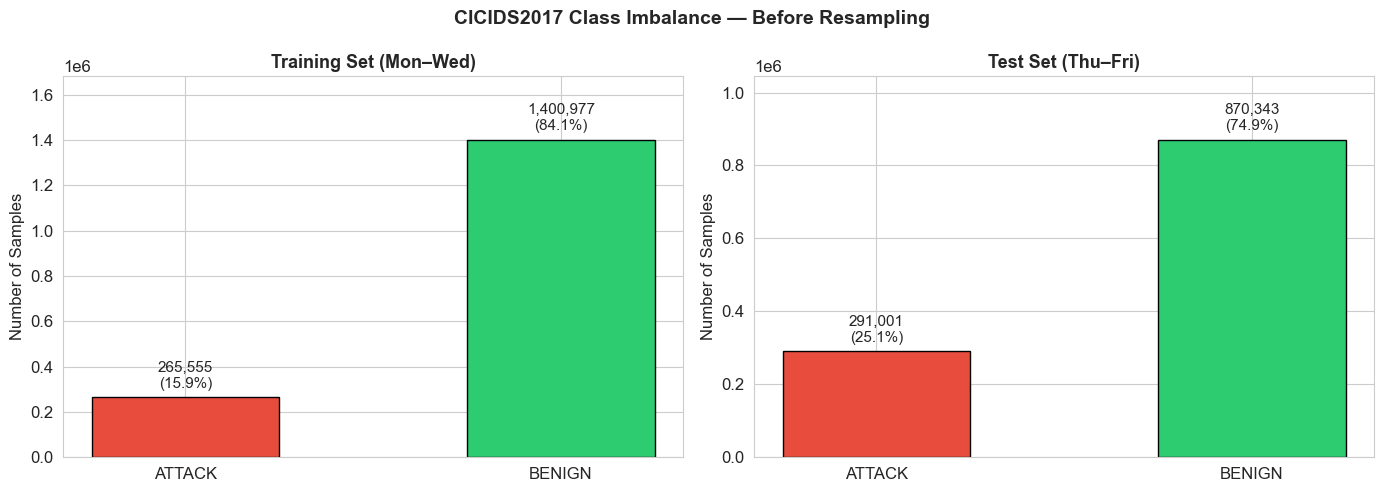

Training imbalance ratio: 5.28:1 (BENIGN:ATTACK)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#2ecc71']

for ax, df, title in [
    (axes[0], df_train, 'Training Set (Mon–Wed)'),
    (axes[1], df_test,  'Test Set (Thu–Fri)')
]:
    counts = df['BinaryLabel'].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Samples')
    ax.set_ylim(0, counts.max() * 1.2)
    for bar, (label, count) in zip(bars, counts.items()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max()*0.02,
                f'{count:,}\n({count/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=11)

plt.suptitle('CICIDS2017 Class Imbalance — Before Resampling',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/01_class_distribution_before_resampling.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = df_train['BinaryLabel'].value_counts()
print(f"Training imbalance ratio: {ratio['BENIGN']/ratio['ATTACK']:.2f}:1 (BENIGN:ATTACK)")


---
## 6. Feature and Label Separation

Features (X) and labels (y) are separated before any resampling or scaling.  
Labels are encoded numerically: **ATTACK = 0, BENIGN = 1**.

The `LabelEncoder` is fitted **only on training labels** then applied to the test set  
using `transform()` — not `fit_transform()` — to prevent test label information  
from influencing the encoding scheme.


In [16]:
# Separate features and labels
X_train = df_train.drop(['Label', 'BinaryLabel'], axis=1)
y_train = df_train['BinaryLabel']
X_test  = df_test.drop(['Label', 'BinaryLabel'], axis=1)
y_test  = df_test['BinaryLabel']

feature_names = X_train.columns.tolist()

# Encode labels — fit on training only, transform both
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)          # transform(), NOT fit_transform()

print("Label encoding scheme:")
for name, code in zip(le.classes_, range(len(le.classes_))):
    print(f"  {name} -> {code}")

print(f"\nX_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Features: {len(feature_names)}")


Label encoding scheme:
  ATTACK -> 0
  BENIGN -> 1

X_train : (1666532, 78)
X_test  : (1161344, 78)
Features: 78


---
## 7. Addressing Class Imbalance — RandomOverSampler

### Resampling Strategy
**RandomOverSampler** duplicates minority class (ATTACK) samples in the training set  
to reduce the class imbalance from 5.3:1 to 1:1.

**SMOTE** (Chawla et al., 2002) was considered as an alternative — it generates  
*synthetic* minority samples by interpolating between nearest neighbours rather than  
duplicating existing ones. However, SMOTE is computationally prohibitive at this scale  
(~265k minority samples × k=5 neighbours across a 78-dimensional feature space).  
RandomOverSampler achieves the same corrective effect with negligible runtime.

### Critical Point — Applied to Training Data ONLY
> ⚠️ Resampling is applied **exclusively to X_train after the temporal split**.  
> The test set remains completely untouched and reflects the true class distribution  
> of real network traffic.  
>  
> This directly addresses the data leakage concern raised in AT2 feedback:  
> class balancing is applied **inside** the modelling pipeline on training data only.


In [17]:
print("Class distribution BEFORE resampling (training):")
unique, counts = np.unique(y_train_enc, return_counts=True)
for code, count in zip(unique, counts):
    print(f"  {le.classes_[code]:<8}: {count:>10,}")
print(f"  Ratio: {counts[1]/counts[0]:.2f}:1 (BENIGN:ATTACK)")

# Apply RandomOverSampler — training data ONLY
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train_enc)

print("\nClass distribution AFTER resampling (training):")
unique2, counts2 = np.unique(y_train_resampled, return_counts=True)
for code, count in zip(unique2, counts2):
    print(f"  {le.classes_[code]:<8}: {count:>10,}")

print(f"\nTraining set: {len(y_train_enc):,} -> {len(y_train_resampled):,} rows")
print(f"Test set    : {len(y_test_enc):,} rows (unchanged)")


Class distribution BEFORE resampling (training):
  ATTACK  :    265,555
  BENIGN  :  1,400,977
  Ratio: 5.28:1 (BENIGN:ATTACK)

Class distribution AFTER resampling (training):
  ATTACK  :  1,400,977
  BENIGN  :  1,400,977

Training set: 1,666,532 -> 2,801,954 rows
Test set    : 1,161,344 rows (unchanged)


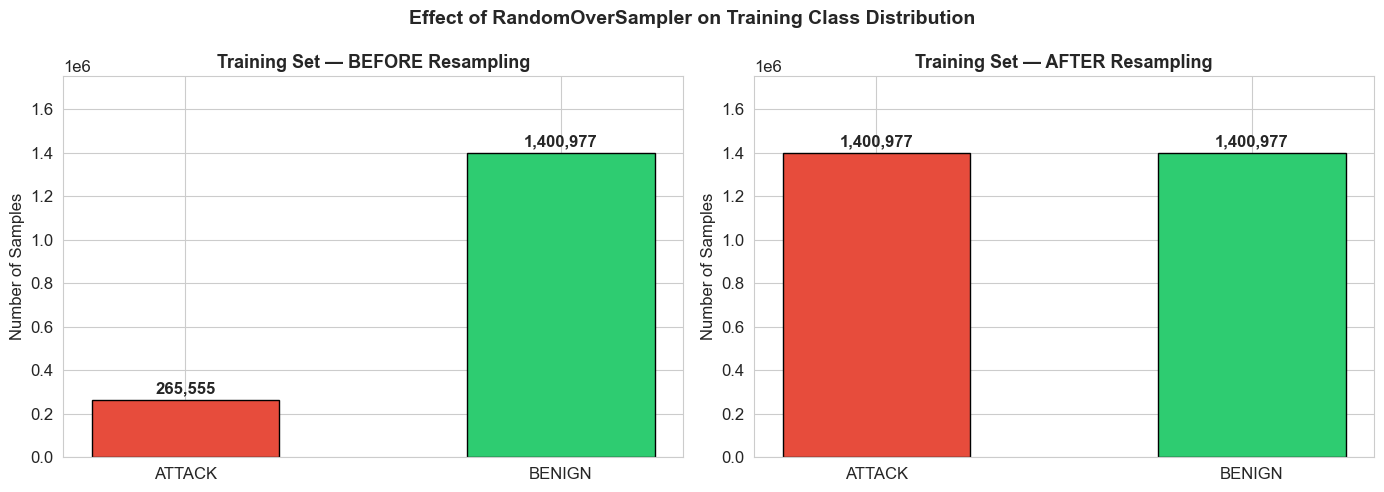

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels_display = le.classes_
colors = ['#e74c3c', '#2ecc71']

before = np.bincount(y_train_enc)
after  = np.bincount(y_train_resampled)

for ax, counts, title in [
    (axes[0], before, 'Training Set — BEFORE Resampling'),
    (axes[1], after,  'Training Set — AFTER Resampling')
]:
    bars = ax.bar(labels_display, counts, color=colors, edgecolor='black', width=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Samples')
    ax.set_ylim(0, max(counts) * 1.25)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.02,
                f'{count:,}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Effect of RandomOverSampler on Training Class Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/02_class_distribution_after_resampling.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Feature Scaling

**StandardScaler** is applied to normalise features to zero mean and unit variance.

This is required for **Isolation Forest**, which is sensitive to feature magnitude.  
Random Forest is not directly affected by scaling, but consistent scaling across  
both models allows fairer comparison of their performance.

### Correct Procedure
1. **Fit** the scaler on `X_train_resampled` only — learns mean and std from training data
2. **Transform** `X_train_resampled` using the fitted scaler
3. **Transform** `X_test` using the **same** fitted scaler (no re-fitting)

Fitting the scaler on the test set would leak test statistics into the training  
normalisation — a form of data leakage that must be avoided.


In [19]:
scaler = StandardScaler()

# Fit on resampled training data ONLY
X_train_scaled = scaler.fit_transform(X_train_resampled)

# Transform test set with the same fitted scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling applied:")
print(f"  X_train_scaled : {X_train_scaled.shape}")
print(f"  X_test_scaled  : {X_test_scaled.shape}")
print(f"\nScaler statistics (first 5 features):")
print(f"  Feature names : {feature_names[:5]}")
print(f"  Fitted mean   : {scaler.mean_[:5].round(3)}")
print(f"  Fitted std    : {scaler.scale_[:5].round(3)}")


Feature scaling applied:
  X_train_scaled : (2801954, 78)
  X_test_scaled  : (1161344, 78)

Scaler statistics (first 5 features):
  Feature names : ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets']
  Fitted mean   : [4.85267800e+03 3.21861864e+07 8.46900000e+00 8.75400000e+00
 4.49217000e+02]
  Fitted std    : [1.50405390e+04 4.41647586e+07 6.39075000e+02 8.47688000e+02
 4.68416300e+03]


---
## 9. Saving Preprocessing Artifacts

The fitted preprocessing objects are saved to `../data/processed/`.  
Notebooks 03 and 04 load these artifacts to ensure **consistent, reproducible**  
transformation is applied at every stage of the pipeline.

**Saved artifacts:**
- `scaler.pkl` — fitted StandardScaler (mean and variance from training data)
- `label_encoder.pkl` — fitted LabelEncoder (ATTACK=0, BENIGN=1)
- `feature_names.pkl` — ordered list of 78 feature names
- `y_train_resampled.npy` — encoded training labels after resampling
- `y_test.npy` — encoded test labels (unmodified)

> Large feature arrays (X_train_scaled, X_test_scaled) are not saved to disk  
> due to size constraints (~2 GB combined). They are regenerated from raw CSVs  
> in Notebook 03 using the saved scaler.


In [20]:
PROCESSED_DIR = '../data/processed'

# Save preprocessing objects
joblib.dump(scaler,        f'{PROCESSED_DIR}/scaler.pkl')
joblib.dump(le,            f'{PROCESSED_DIR}/label_encoder.pkl')
joblib.dump(feature_names, f'{PROCESSED_DIR}/feature_names.pkl')

# Save label arrays
np.save(f'{PROCESSED_DIR}/y_train_resampled.npy', y_train_resampled)
np.save(f'{PROCESSED_DIR}/y_test.npy',            y_test_enc)

print("Saved to ../data/processed/:")
for fname in sorted(os.listdir(PROCESSED_DIR)):
    fpath = os.path.join(PROCESSED_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname:<30} {size_kb:>8.1f} KB")


Saved to ../data/processed/:
  feature_names.pkl                   1.4 KB
  label_encoder.pkl                   0.5 KB
  scaler.pkl                          4.1 KB
  y_test.npy                       9073.1 KB
  y_train_resampled.npy           21890.4 KB


---
## 10. Preprocessing Summary

| Step | Action | Outcome |
|---|---|---|
| Data Loading | 8 CICIDS2017 CSVs, temporal split | Train: Mon–Wed, Test: Thu–Fri |
| Data Cleaning | Replace inf → NaN, drop NaN rows | <0.1% rows removed, no imputation |
| Binary Labels | BENIGN vs ATTACK | Honest generalisation evaluation |
| Class Imbalance | RandomOverSampler on X_train only | 5.3:1 → 1:1 ratio, no test leakage |
| Feature Scaling | StandardScaler fitted on X_train only | No test statistics in normalisation |
| Artifacts Saved | scaler, encoder, feature names, labels | Reproducible pipeline |

### Data Leakage Prevention Summary
- ✅ Temporal split: no correlated flows shared across train/test
- ✅ LabelEncoder: `fit` on train, `transform` on test
- ✅ RandomOverSampler: applied to training data only, after the split
- ✅ StandardScaler: `fit` on train, `transform` on test

### Next Step
**Notebook 03 — Model Training**: Random Forest with cross-validation and  
Isolation Forest with contamination tuning, trained on the preprocessed data.
